In [1]:
# Importing the Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import stats

In [2]:
# Importing the Dataset
df = pd.read_csv('merged_file_MPT.csv')
print(df)

            M    P     T   Mach         Re  Alpha      Cl       Cd      Cm  \
0        0.01  0.1  0.06  0.001    10000.0   -5.0 -0.5260  0.07059  0.0224   
1        0.01  0.1  0.06  0.001    10000.0   -4.0 -0.4579  0.05448  0.0106   
2        0.01  0.1  0.06  0.001    10000.0   -3.0 -0.3588  0.04090  0.0137   
3        0.01  0.1  0.06  0.001    10000.0   -2.0 -0.1194  0.03233 -0.0146   
4        0.01  0.1  0.06  0.001    10000.0   -1.0 -0.0321  0.03188 -0.0111   
...       ...  ...   ...    ...        ...    ...     ...      ...     ...   
1220409  0.04  0.4  0.23  0.300  1000000.0    5.0  0.9268  0.01145 -0.0698   
1220410  0.04  0.4  0.23  0.300  1000000.0    7.0  1.1296  0.01387 -0.0651   
1220411  0.04  0.4  0.23  0.300  1000000.0    8.0  1.2143  0.01563 -0.0607   
1220412  0.04  0.4  0.23  0.300  1000000.0    9.0  1.2919  0.01802 -0.0559   
1220413  0.04  0.4  0.23  0.300  1000000.0   10.0  1.3653  0.02095 -0.0513   

             Cdp  
0        0.05654  
1        0.03989  
2     

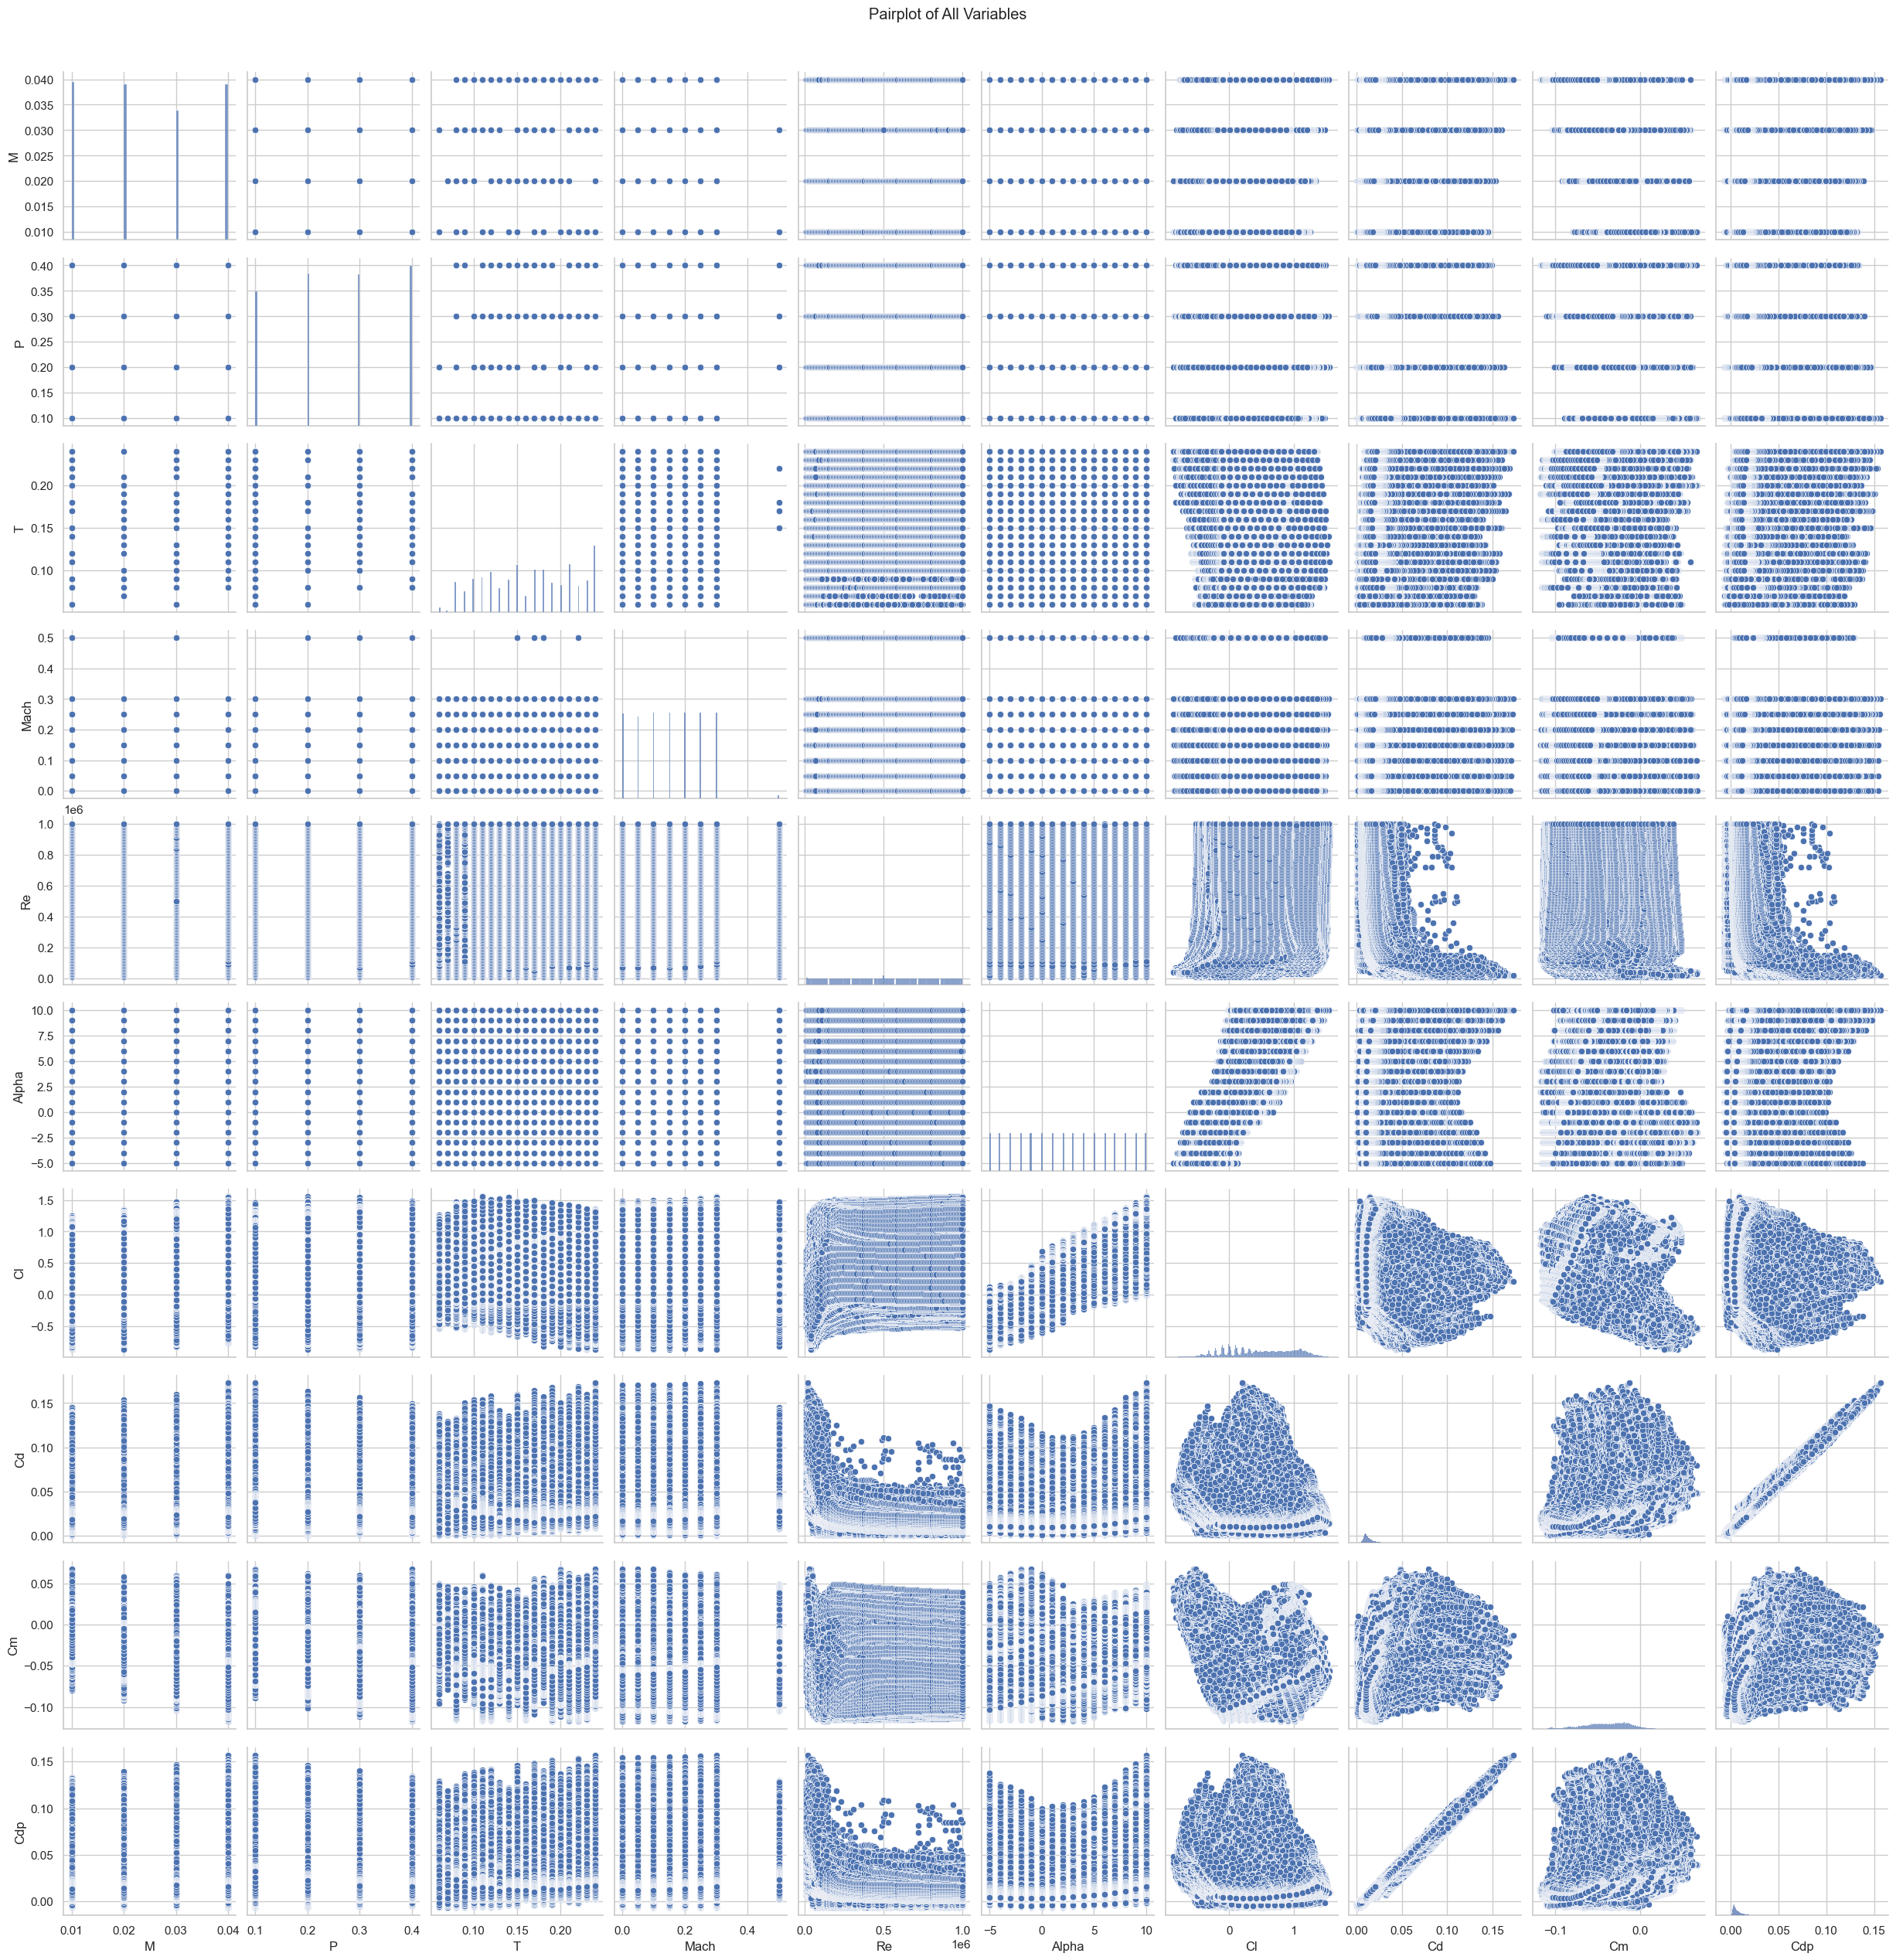

In [3]:
# Set Seaborn style for better visualization
sns.set(style="whitegrid")

# Pairplot to visualize relationships between all variables
sns.pairplot(df)
plt.suptitle("Pairplot of All Variables", y=1.02)
plt.show()

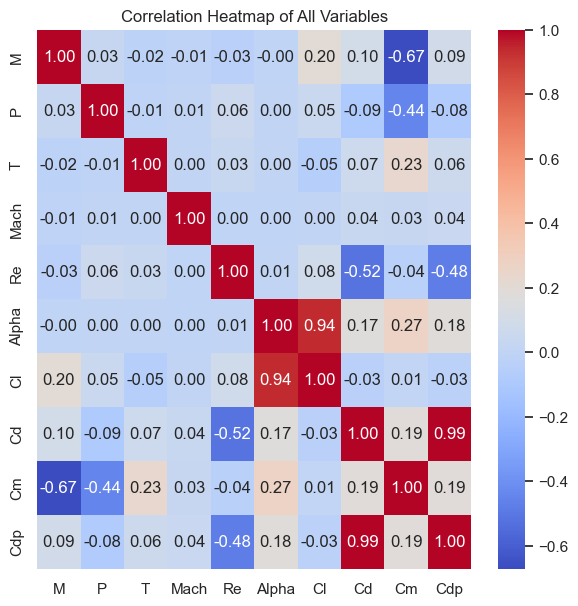

In [4]:
# Correlation heatmap to see correlation between variables
plt.figure(figsize=(7, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of All Variables")
plt.show()

### Scatterplot for Inputs vs Outputs

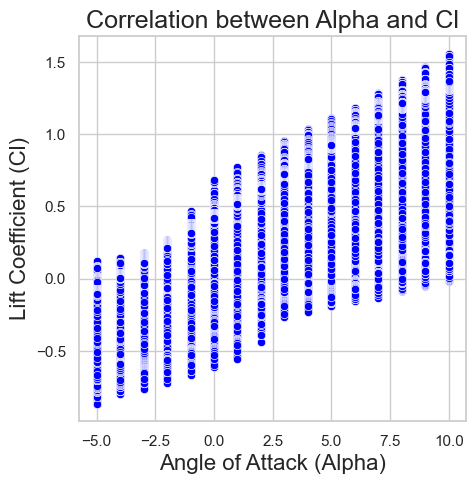

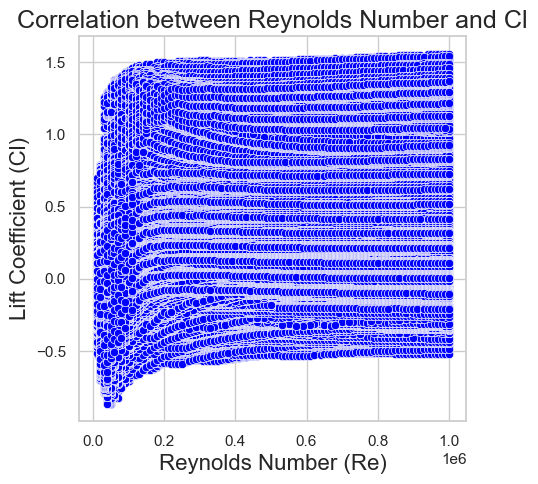

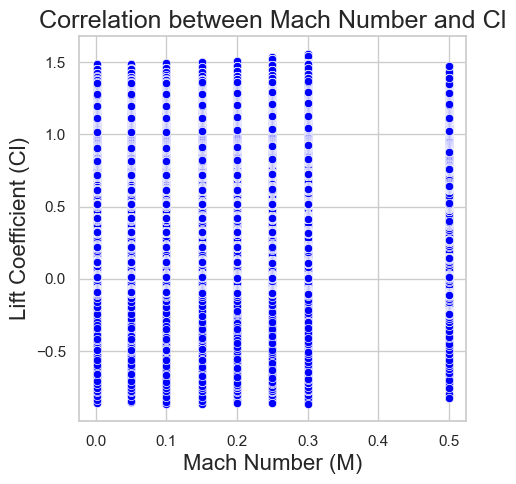

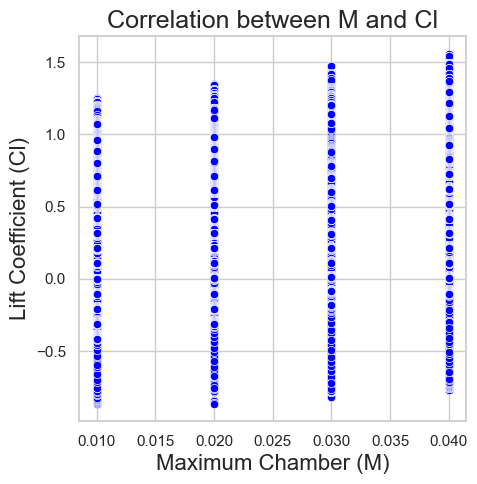

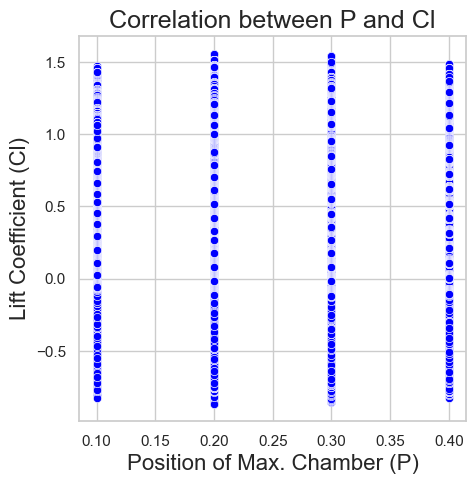

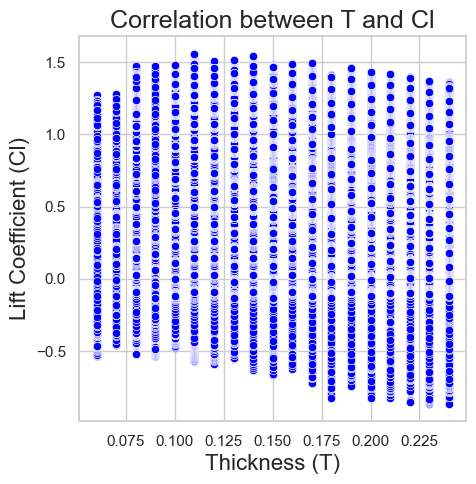

In [6]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="Alpha", y="Cl", color="blue")
plt.title("Correlation between Alpha and Cl", fontsize = 18)
plt.xlabel ("Angle of Attack (Alpha)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="Re", y="Cl", color="blue")
plt.title("Correlation between Reynolds Number and Cl", fontsize = 18)
plt.xlabel ("Reynolds Number (Re)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="Mach", y="Cl", color="blue")
plt.title("Correlation between Mach Number and Cl", fontsize = 18)
plt.xlabel ("Mach Number (M)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="M", y="Cl", color="blue")
plt.title("Correlation between M and Cl", fontsize = 18)
plt.xlabel ("Maximum Chamber (M)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="P", y="Cl", color="blue")
plt.title("Correlation between P and Cl", fontsize = 18)
plt.xlabel ("Position of Max. Chamber (P)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x="T", y="Cl", color="blue")
plt.title("Correlation between T and Cl", fontsize = 18)
plt.xlabel ("Thickness (T)", fontsize = 16)
plt.ylabel ("Lift Coefficient (Cl)", fontsize = 16)
plt.show()

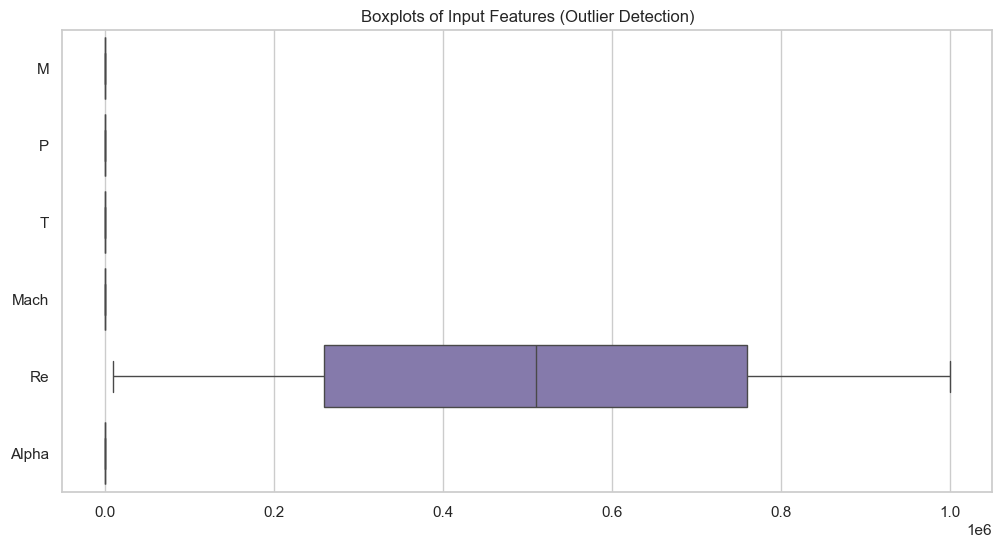

In [10]:
# Boxplots to detect Outliers in Each Feature
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['M', 'P', 'T', 'Mach', 'Re', 'Alpha']], orient="h")
plt.title("Boxplots of Input Features (Outlier Detection)")
plt.show()

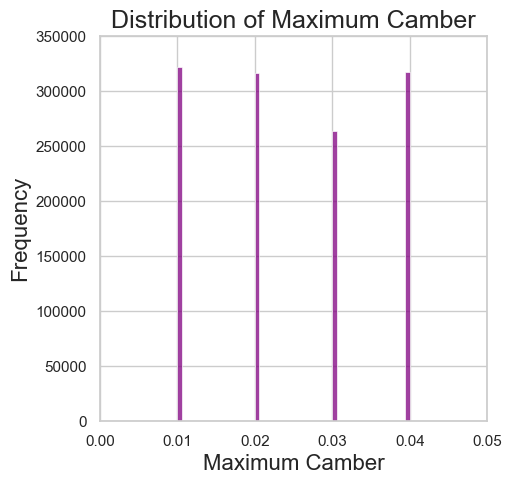

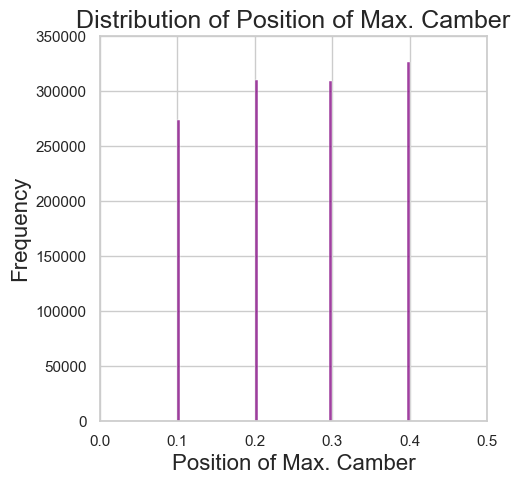

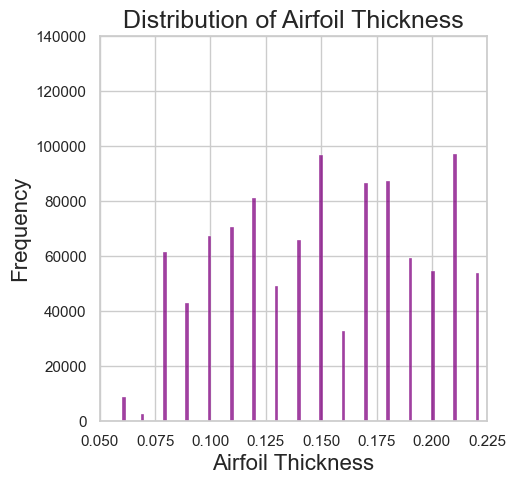

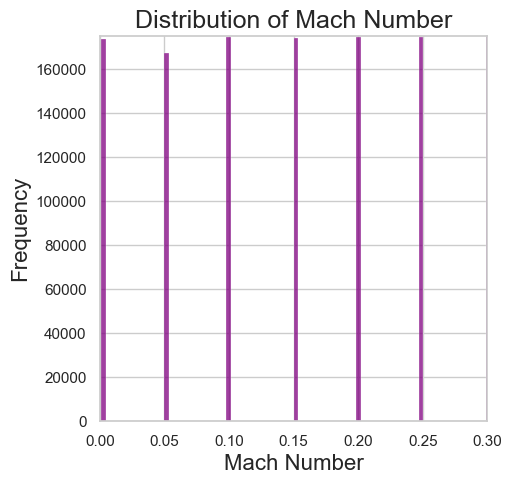

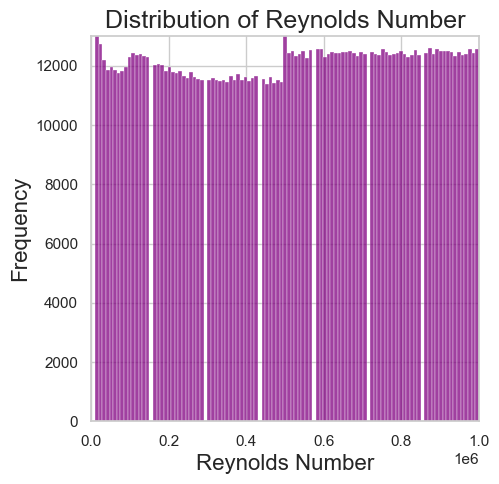

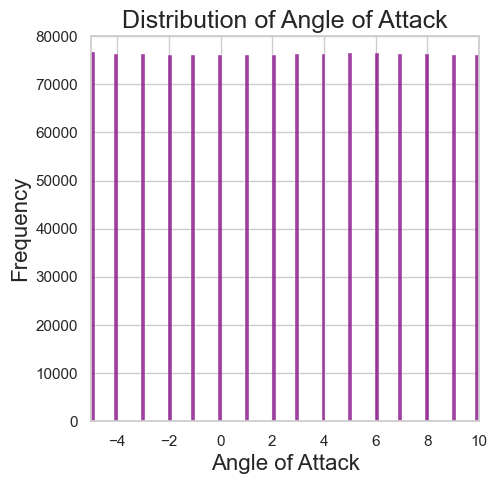

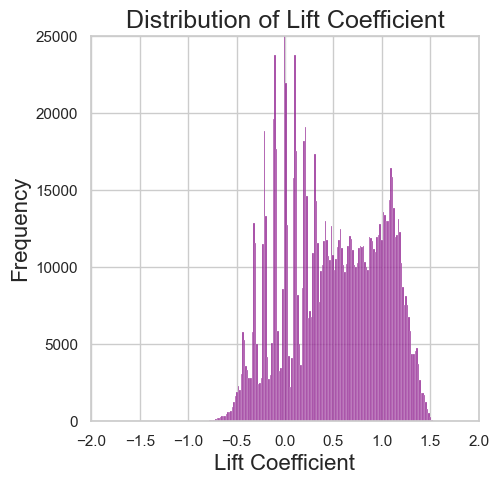

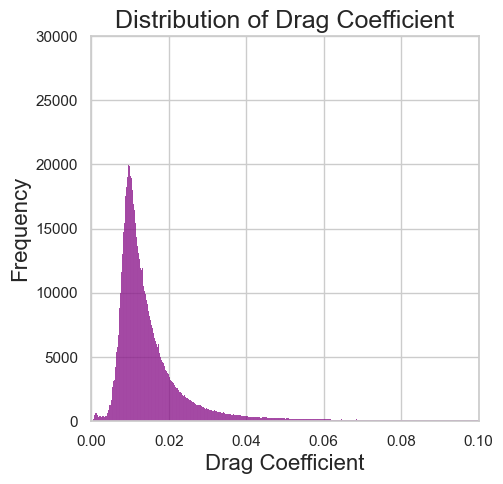

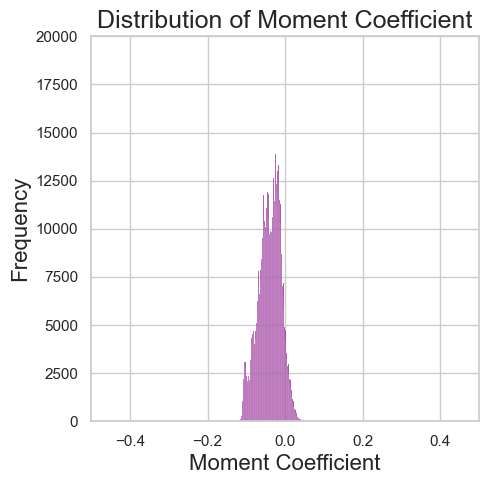

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping features to custom axis labels
feature_labels = {
    'M': 'Maximum Camber',
    'P': 'Position of Max. Camber',
    'T': 'Airfoil Thickness',
    'Mach': 'Mach Number',
    'Re': 'Reynolds Number',
    'Alpha': 'Angle of Attack',
    'Cl': 'Lift Coefficient',
    'Cd': 'Drag Coefficient',
    'Cm': 'Moment Coefficient'
}

# Set axis limits (example ranges, adjust as needed)
axis_limits = {
    'M': (0, 0.05, 0, 350000),
    'P': (0, 0.5, 0, 350000),
    'T': (0.05, 0.225, 0, 140000),
    'Mach': (0, 0.3, 0, 175000),
    'Re': (0, 1e6, 0, 13000),
    'Alpha': (-5, 10, 0, 80000),
    'Cl': (-2, 2, 0, 25000),
    'Cd': (0, 0.1, 0, 30000),
    'Cm': (-0.5, 0.5, 0, 20000)
}

# Plot distributions
for feature in feature_labels.keys():
    plt.figure(figsize=(5, 5))
    sns.histplot(df[feature], kde=False, color='purple')
    plt.title(f"Distribution of {feature_labels[feature]}", fontsize=18)
    plt.xlabel(feature_labels[feature], fontsize=16)
    plt.ylabel("Frequency", fontsize=16)

    # Apply axis limits
    x_min, x_max, y_min, y_max = axis_limits[feature]
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.show()


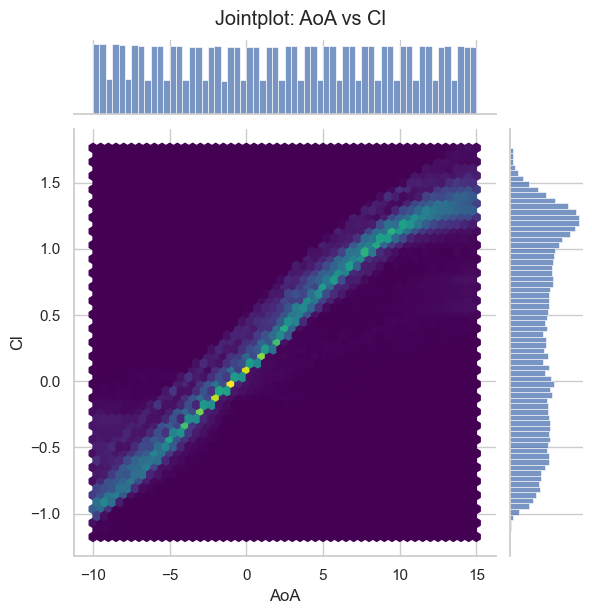

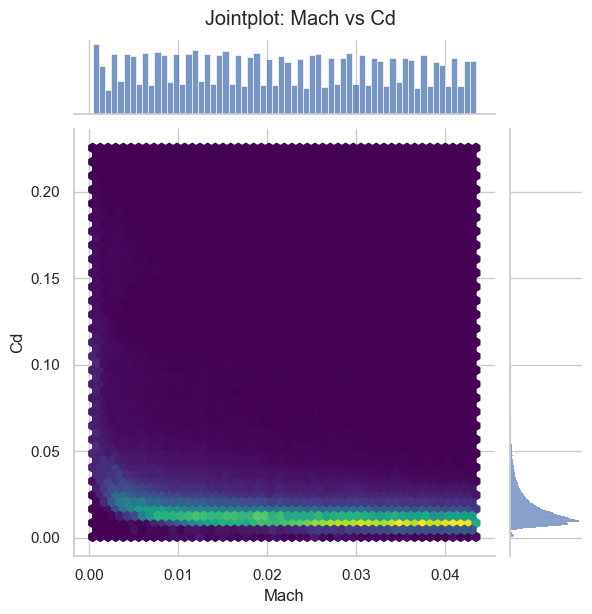

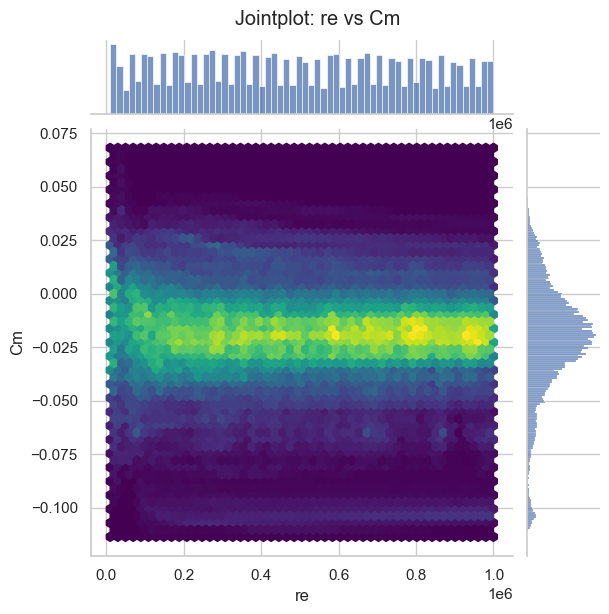

In [ ]:
# Jointplots for Key Relationships
sns.jointplot(data=df, x="AoA", y="Cl", kind="hex", cmap="viridis")
plt.suptitle("Jointplot: AoA vs Cl", y=1.02)
plt.show()

sns.jointplot(data=df, x="Mach", y="Cd", kind="hex", cmap="viridis")
plt.suptitle("Jointplot: Mach vs Cd", y=1.02)
plt.show()

sns.jointplot(data=df, x="re", y="Cm", kind="hex", cmap="viridis")
plt.suptitle("Jointplot: re vs Cm", y=1.02)
plt.show()

In [ ]:
# Pairplot with Hue set to Output Variables (Cl, Cd, Cm)
sns.pairplot(df, vars=['m', 'p', 't', 'Mach', 're', 'AoA'], hue='Cl', palette='coolwarm')
plt.suptitle("Pairwise Relationships with Cl as Hue", y=1.02)
plt.show()

sns.pairplot(df, vars=['m', 'p', 't', 'Mach', 're', 'AoA'], hue='Cd', palette='coolwarm')
plt.suptitle("Pairwise Relationships with Cd as Hue", y=1.02)
plt.show()

sns.pairplot(df, vars=['m', 'p', 't', 'Mach', 're', 'AoA'], hue='Cm', palette='coolwarm')
plt.suptitle("Pairwise Relationships with Cm as Hue", y=1.02)
plt.show()